In [1]:
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt 

# aerosol burden

## interstitial

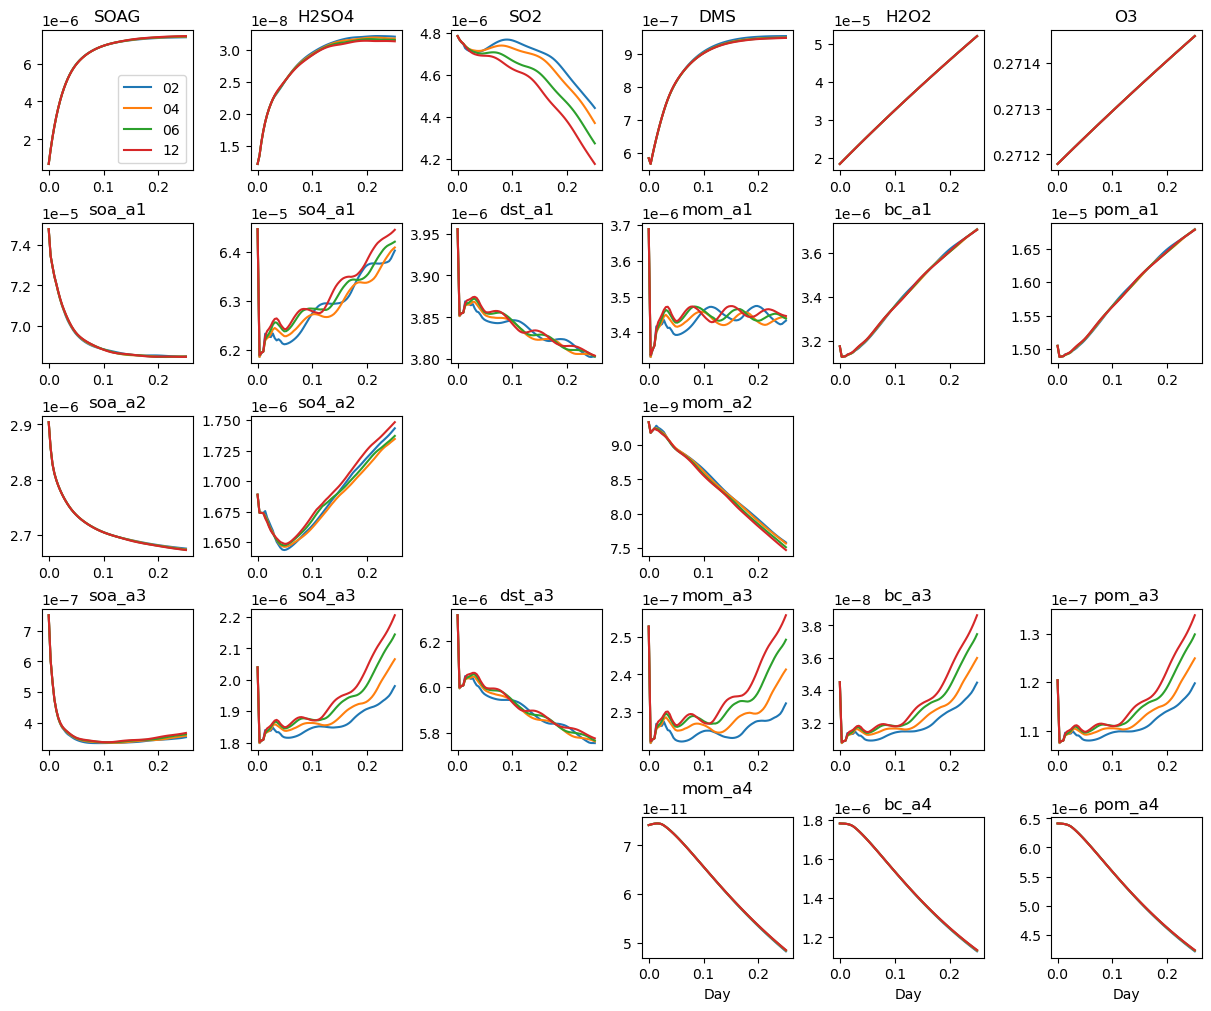

In [ ]:
def plot_time_series(cases, axs):
    names = cases 
    for case, name, ls, c in zip(cases, names, ['-', '-', '-', '-'], ['C0', 'C1', 'C2', 'C3']):
        file = f'/pscratch/sd/m/meng/dp_screamxx/mamxx/scream_dpxx_DYCOMSrf01/run_{case}/scream_dpxx_DYCOMSrf01.fullfield.INSTANT.nsteps_x1.1999-07-10-00000.nc'
        ds = xr.open_dataset(file, decode_cf=False)

        area = ds['area'].values  # in m²

        p_int = ds['p_int'].values

        var1 = ds['SOAG']
        var2 = ds['H2SO4']
        var3 = ds['SO2']
        var4 = ds['DMS']
        var5 = ds['H2O2']
        var6 = ds['O3']

        dp = p_int[:, :, 1:] - p_int[:, :, :-1]
        soag = var1.values * dp / 9.81
        h2so4 = var2.values * dp / 9.81
        so2 = var3.values * dp / 9.81
        dms = var4.values * dp / 9.81
        h2o2 = var5.values * dp / 9.81
        o3 = var6.values * dp / 9.81

        for v, ax, vname in zip([soag, h2so4, so2, dms, h2o2, o3], axs[0], ['SOAG', 'H2SO4', 'SO2', 'DMS', 'H2O2', 'O3']):
            tm = np.nansum(v, axis=2)  # column mass loading [kg m-2], shape (time, ncol)
            burden_tg = np.nansum(tm * area, axis=1) * 1e-9  # domain burden [Tg]

            if vname == 'O3' and case == 'linoz':
                ax2 = ax.twinx()
                ax2.plot(ds.time, burden_tg, c=c, label=name, ls=ls)
            else:
                ax.plot(ds.time, burden_tg, c=c, label=name, ls=ls)
            ax.set_title(vname)

        for axr, mode in zip(axs[1:], ['a1', 'a2', 'a3', 'a4']):
            for ax, v in zip(axr, ['soa', 'so4', 'dst', 'mom', 'bc', 'pom']):
                if v + '_' + mode in ds.variables:
                    var = ds[v + '_' + mode].values * dp / 9.81
                    tm = np.nansum(var, axis=2)
                    burden_tg = np.nansum(tm * area, axis=1) * 1e-9
                    ax.plot(ds.time, burden_tg, c=c, ls=ls)
                    ax.set_title(v + '_' + mode)
                else:
                    ax.axison = False

        for ax in axs[-1]:
            ax.set_xlabel('Day')

    axs[0, 0].legend()


fig, axs = plt.subplots(5, 6, constrained_layout=True, figsize=(12, 10))
plot_time_series(['02', '04', '06', '12'], axs)

## interstitial + cloudborne

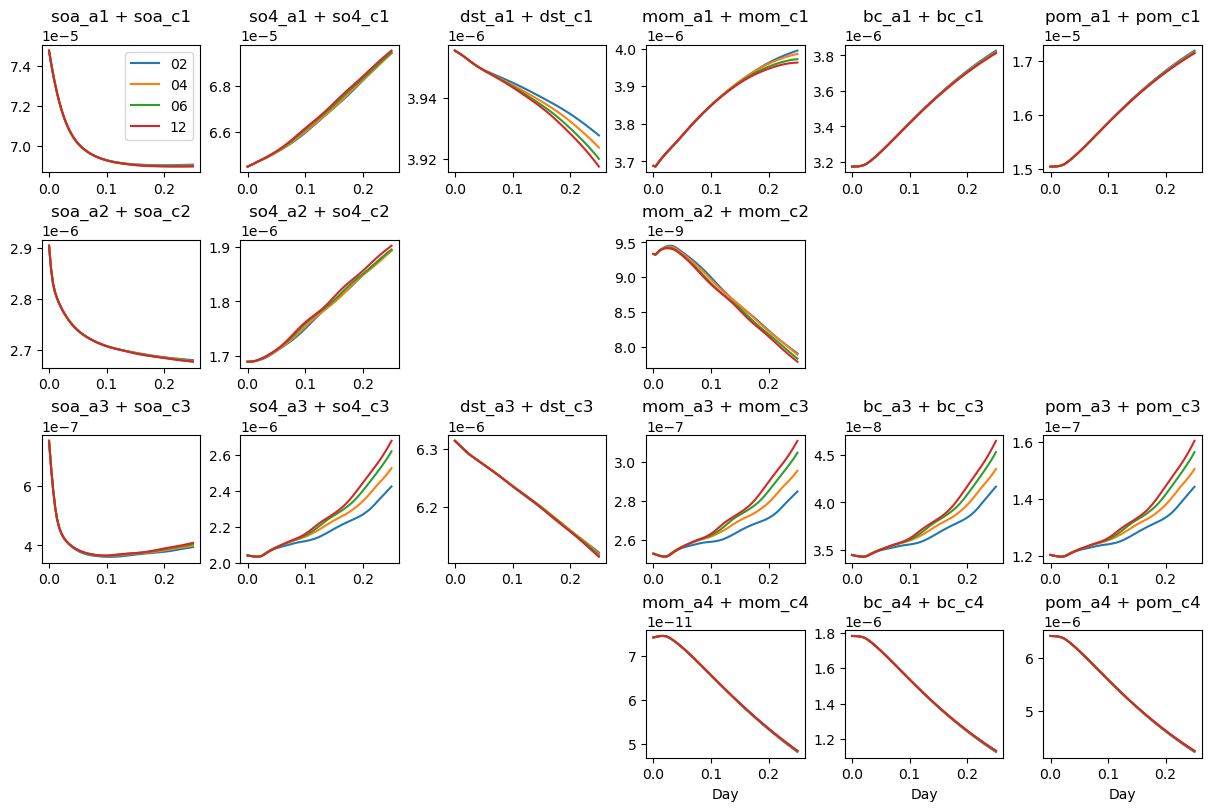

In [3]:
def plot_time_series(cases, axs):
    names = cases 
    for case, name, ls, c in zip(cases, names, ['-', '-', '-', '-'], ['C0', 'C1', 'C2', 'C3']):
        file = f'/pscratch/sd/m/meng/dp_screamxx/mamxx/scream_dpxx_DYCOMSrf01/run_{case}/scream_dpxx_DYCOMSrf01.fullfield.INSTANT.nsteps_x1.1999-07-10-00000.nc'
        ds = xr.open_dataset(file, decode_cf=False)

        area = ds['area'].values 

        p_int = ds['p_int'].values
        dp = p_int[:, :, 1:] - p_int[:, :, :-1]

        for axr, mode in zip(axs, ['1', '2', '3', '4']):
            for ax, v in zip(axr, ['soa', 'so4', 'dst', 'mom', 'bc', 'pom']):
                if v + '_a' + mode in ds.variables:
                    var = (ds[v + '_a' + mode].values + ds[v + '_c' + mode].values) * dp / 9.81
                    tm = np.nansum(var, axis=2)
                    burden_tg = np.nansum(tm * area, axis=1) * 1e-9
                    ax.plot(ds.time, burden_tg, c=c, ls=ls, label=name)
                    ax.set_title(v + '_a' + mode + ' + ' + v + '_c' + mode)
                else:
                    ax.axison = False

        for ax in axs[-1]:
            ax.set_xlabel('Day')

    axs[0, 0].legend()


fig, axs = plt.subplots(4, 6, constrained_layout=True, figsize=(12, 8))
plot_time_series(['02', '04', '06', '12'], axs)

# domain average cloud properties

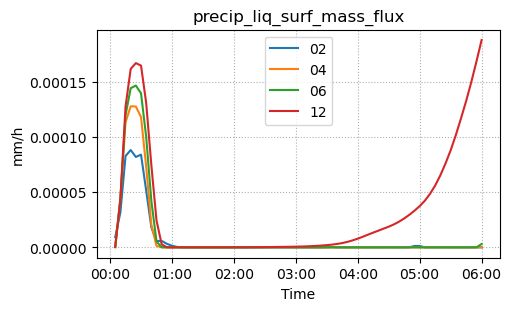

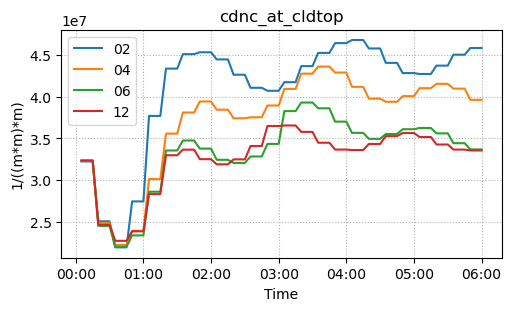

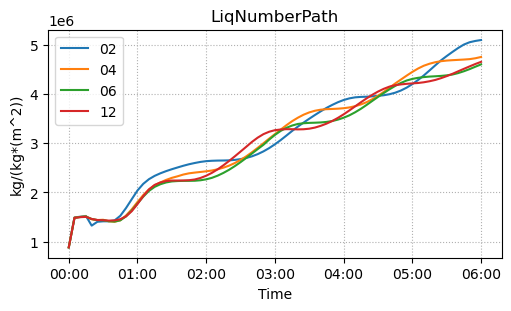

In [4]:
import matplotlib.dates as mdates

cases = ['02', '04', '06', '12']
cloud_vars = ['precip_liq_surf_mass_flux', 'cdnc_at_cldtop', 'LiqNumberPath', ]
cloud_2d = ['rainfrac', 'cldfrac_liq', 'cldfrac_tot_for_analysis', 'eff_radius_qc']

PRECIP_SCALE = 3.6e6
PRECIP_UNITS = 'mm/h'

for v_cloud in cloud_vars:
    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)
    v = v_cloud + '_horiz_avg'
    units = ''
    
    for case in cases[:]:
        file = f'/pscratch/sd/m/meng/dp_screamxx/mamxx/scream_dpxx_DYCOMSrf01/run_{case}/scream_dpxx_DYCOMSrf01.horiz_avg.INSTANT.nsteps_x1.1999-07-10-00000.nc'
        ds = xr.open_dataset(file)   
    
        if v in ds:
            data = ds[v]
            if v_cloud == 'precip_liq_surf_mass_flux':
                data = data * PRECIP_SCALE
                units = PRECIP_UNITS
            elif not units:
                units = ds[v].attrs.get('units', '')
            ax.plot(ds['time'], data, label=f'{case}')
            ax.set_title(v.replace('_horiz_avg', ''))
        else:
            print(f"Variable {v} not found in dataset for case {case}.")
            
    ax.set_xlabel('Time')
    ax.set_ylabel(units)
    ax.grid(ls=':')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

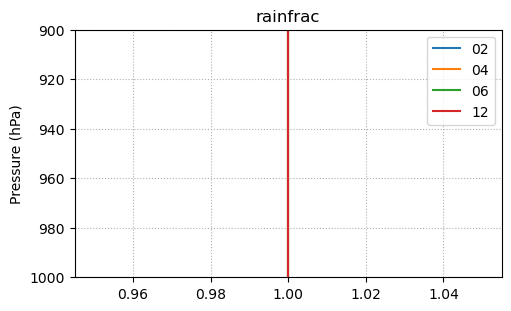

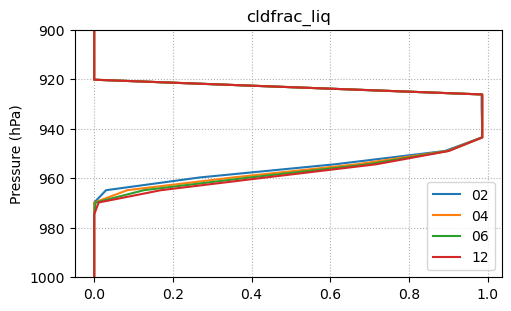

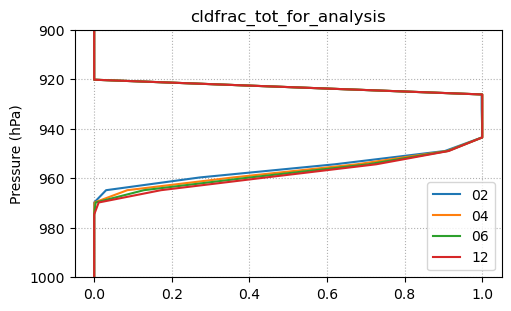

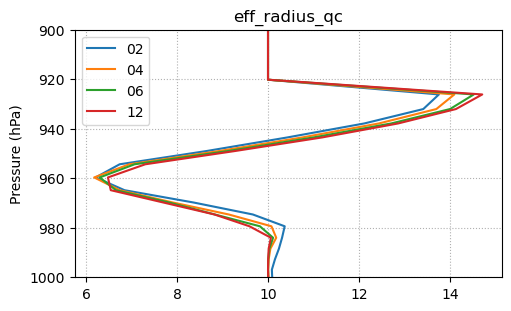

In [5]:
for v_cloud in cloud_2d:
    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)
    v = v_cloud + '_horiz_avg'
    units = ''
    
    for case in cases[:]:
        file = f'/pscratch/sd/m/meng/dp_screamxx/mamxx/scream_dpxx_DYCOMSrf01/run_{case}/scream_dpxx_DYCOMSrf01.horiz_avg.INSTANT.nsteps_x1.1999-07-10-00000.nc'
        ds = xr.open_dataset(file)   
    
        if v in ds:
            data = ds[v].mean(dim='time')  
            if v_cloud == 'precip_liq_surf_mass_flux':
                data = data * PRECIP_SCALE
                units = PRECIP_UNITS
            elif not units:
                units = ds[v].attrs.get('units', '')
            plev = ds['p_mid_horiz_avg'].mean(dim='time') / 100.0
            ax.plot(data, plev, label=f'{case}')
            ax.set_title(v.replace('_horiz_avg', ''))
        else:
            print(f"Variable {v} not found in dataset for case {case}.")
            
    ax.set_ylabel('Pressure (hPa)')
    ax.set_ylim(1000, 900)
    ax.grid(ls=':')
    ax.legend()